# Repaso de Machine Learning — Regresión Lineal desde cero

Notebook de repaso teórico-práctico. Implementamos **regresión lineal simple** y **regresión
lineal múltiple** derivando las fórmulas nosotros mismos y programándolas sin usar ninguna
librería de Machine Learning (nada de `sklearn.linear_model`, ni `statsmodels`).

**Alcance de "sin librerías" (para que quede explícito):** usamos `numpy` como calculadora de
álgebra lineal (sumas, medias, multiplicación e inversión de matrices) — son operaciones
aritméticas, no el algoritmo de regresión en sí. Lo que programamos nosotros es **la fórmula
de la regresión**: las ecuaciones normales, y también una versión por **descenso de gradiente**.
`scikit-learn` solo aparece al final, como verificación de que nuestro resultado manual es correcto.

**Estructura:**
1. Regresión lineal simple (una variable) — ecuación cerrada
2. Regresión lineal simple — descenso de gradiente (conecta con cómo entrenaremos el MLP del TFM)
3. Regresión lineal múltiple (varias variables) — ecuación normal matricial
4. Verificación contra `scikit-learn`
5. Conexión con el proyecto de TFM


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducibilidad
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Regresión lineal simple

### 1.1 El modelo

Con una sola variable explicativa $x$, el modelo es:

$$\hat{y}_i = \beta_0 + \beta_1 x_i$$

- $\beta_0$ — intercepto (valor de $\hat y$ cuando $x=0$)
- $\beta_1$ — pendiente (cuánto cambia $\hat y$ por cada unidad que cambia $x$)

### 1.2 ¿Qué significa "ajustar" el modelo?

Encontrar los $\beta_0, \beta_1$ que minimizan la **suma de errores al cuadrado** (SSE, de
*Sum of Squared Errors*) entre lo predicho y lo observado:

$$S(\beta_0,\beta_1) = \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2$$

Elevar al cuadrado castiga más los errores grandes y hace que el problema tenga una solución
matemática limpia (derivable en todas partes, con un único mínimo).

### 1.3 Derivación de la solución (ecuaciones normales)

Derivamos $S$ respecto a $\beta_0$ y $\beta_1$, e igualamos a cero (condición de mínimo):

$$\frac{\partial S}{\partial \beta_0} = -2\sum_i (y_i - \beta_0 - \beta_1 x_i) = 0
\;\Rightarrow\; \bar y = \beta_0 + \beta_1 \bar x$$

$$\frac{\partial S}{\partial \beta_1} = -2\sum_i x_i(y_i - \beta_0 - \beta_1 x_i) = 0$$

Sustituyendo $\beta_0 = \bar y - \beta_1 \bar x$ en la segunda ecuación y despejando, se llega a:

$$\boxed{\beta_1 = \dfrac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sum_i (x_i-\bar x)^2}
\qquad \beta_0 = \bar y - \beta_1 \bar x}$$

Es decir: la pendiente es la **covarianza** entre $x$ e $y$ dividida entre la **varianza** de
$x$. Tiene sentido: si $x$ e $y$ se mueven mucho juntas (covarianza alta) relativo a cuánto
se mueve $x$ por sí sola (varianza de $x$), la pendiente es grande.


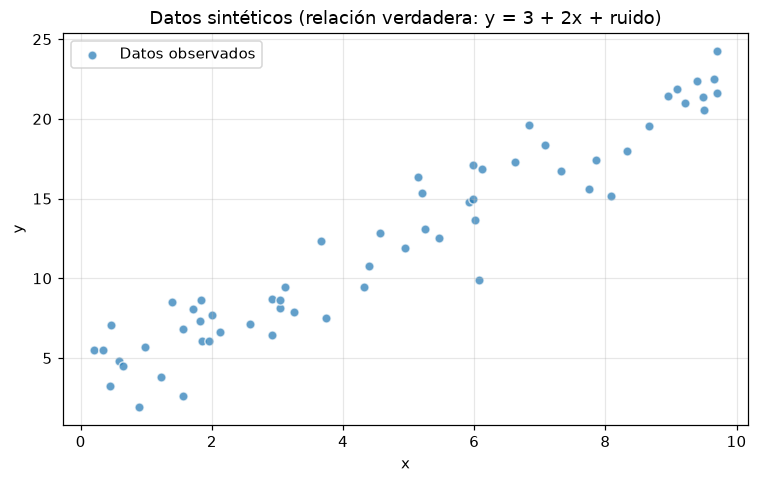

In [2]:
# Datos sintéticos con relación VERDADERA conocida: y = 3 + 2x + ruido
# Conocer la verdad nos permite comparar "lo que el modelo estima" contra "lo que realmente es".
n = 60
beta0_true, beta1_true = 3.0, 2.0

x = np.random.uniform(0, 10, n)
ruido = np.random.normal(0, 2.0, n)
y = beta0_true + beta1_true * x + ruido

plt.figure(figsize=(7, 4.5))
plt.scatter(x, y, alpha=0.7, edgecolor="white", label="Datos observados")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Datos sintéticos (relación verdadera: y = 3 + 2x + ruido)")
plt.legend(); plt.tight_layout(); plt.show()


In [3]:
def fit_regresion_simple(x, y):
    '''Ajusta y = b0 + b1*x por mínimos cuadrados, vía ecuaciones normales.'''
    x_media, y_media = x.mean(), y.mean()
    b1 = np.sum((x - x_media) * (y - y_media)) / np.sum((x - x_media) ** 2)
    b0 = y_media - b1 * x_media
    return b0, b1

b0_hat, b1_hat = fit_regresion_simple(x, y)
print(f"Verdadero:  beta0 = {beta0_true:.3f}   beta1 = {beta1_true:.3f}")
print(f"Estimado:   beta0 = {b0_hat:.3f}   beta1 = {b1_hat:.3f}")


Verdadero:  beta0 = 3.000   beta1 = 2.000
Estimado:   beta0 = 3.177   beta1 = 1.926


### 1.4 Visualización: datos, recta ajustada y recta verdadera

Si el ajuste es bueno, la recta estimada (naranja) debería quedar muy cerca de la recta
verdadera (verde discontinua) — la diferencia entre ambas es puro efecto del ruido aleatorio
que añadimos a una muestra finita.


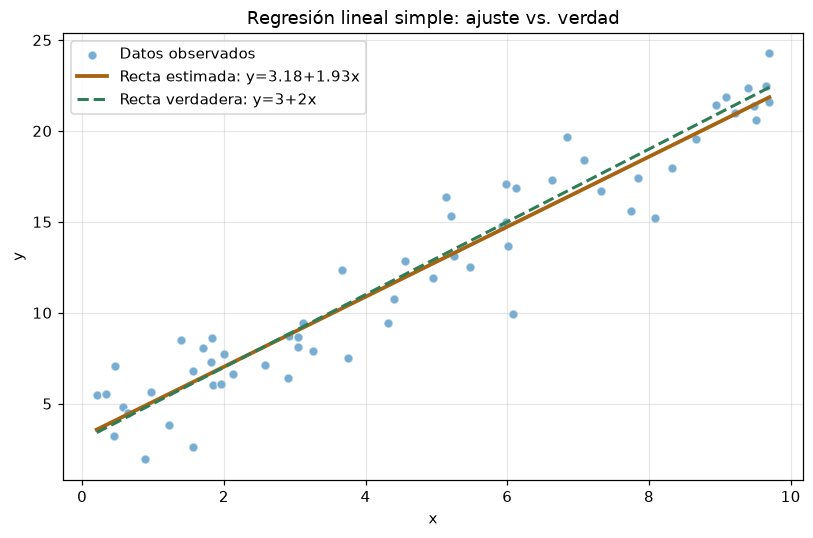

In [4]:
x_linea = np.linspace(x.min(), x.max(), 100)
y_estimada = b0_hat + b1_hat * x_linea
y_verdadera = beta0_true + beta1_true * x_linea

plt.figure(figsize=(7.5, 5))
plt.scatter(x, y, alpha=0.6, edgecolor="white", label="Datos observados")
plt.plot(x_linea, y_estimada, color="#A66412", linewidth=2.5, label=f"Recta estimada: y={b0_hat:.2f}+{b1_hat:.2f}x")
plt.plot(x_linea, y_verdadera, color="#2E7D57", linestyle="--", linewidth=2, label=f"Recta verdadera: y={beta0_true:.0f}+{beta1_true:.0f}x")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Regresión lineal simple: ajuste vs. verdad")
plt.legend(); plt.tight_layout(); plt.show()


### 1.5 Residuos

Un residuo es lo que el modelo **no** logra explicar: $e_i = y_i - \hat y_i$. Si el modelo es
razonable, los residuos deberían repartirse al azar alrededor de cero, sin ningún patrón.


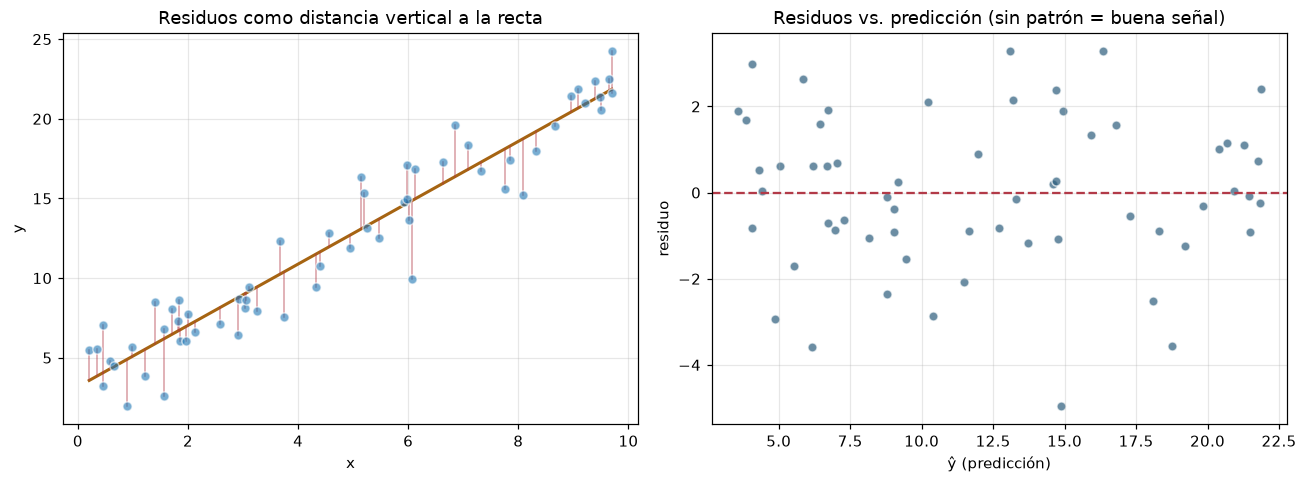

In [5]:
y_pred = b0_hat + b1_hat * x
residuos = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel izquierdo: lineas de residuo sobre el scatter
axes[0].scatter(x, y, alpha=0.6, edgecolor="white", zorder=3)
axes[0].plot(x_linea, y_estimada, color="#A66412", linewidth=2, zorder=2)
for xi, yi, ypi in zip(x, y, y_pred):
    axes[0].plot([xi, xi], [yi, ypi], color="#B23A48", alpha=0.5, linewidth=1)
axes[0].set_title("Residuos como distancia vertical a la recta")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

# Panel derecho: residuos vs. predicción (debe verse como "ruido", sin patrón)
axes[1].scatter(y_pred, residuos, alpha=0.7, edgecolor="white", color="#2C5D7C")
axes[1].axhline(0, color="#B23A48", linestyle="--")
axes[1].set_title("Residuos vs. predicción (sin patrón = buena señal)")
axes[1].set_xlabel("ŷ (predicción)"); axes[1].set_ylabel("residuo")

plt.tight_layout(); plt.show()


### 1.6 ¿Qué tan bueno es el ajuste? — $R^2$

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i - \bar y)^2}$$

Compara el error del modelo ($SS_{res}$) contra el error de "no hacer nada mejor que predecir
siempre la media" ($SS_{tot}$). $R^2=1$ es ajuste perfecto; $R^2=0$ significa que el modelo no
aporta nada sobre predecir la media.


In [6]:
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"R² = {r2:.4f}  →  el modelo explica el {r2*100:.1f}% de la variabilidad de y")


R² = 0.9165  →  el modelo explica el 91.7% de la variabilidad de y


## 2. La misma regresión simple, resuelta por descenso de gradiente

Las ecuaciones normales dan la solución exacta de un solo golpe — pero es un caso afortunado
de la regresión lineal (el problema es "convexo cuadrático" y tiene forma cerrada). La mayoría
de los modelos de ML (incluida la red neuronal que usaremos más adelante en el TFM) **no**
tienen una fórmula cerrada, y se resuelven **iterando**: dar pasitos que van reduciendo el
error, uno a uno. Esa técnica se llama **descenso de gradiente**, y merece la pena verla aquí
con el ejemplo más simple posible, porque es exactamente la misma idea que usaremos para
entrenar el MLP.

### 2.1 La idea

1. Empezamos con $\beta_0,\beta_1$ al azar (mal ajuste, a propósito).
2. Calculamos el **gradiente** de la pérdida $S(\beta_0,\beta_1)$ — la dirección en la que
   $S$ crece más rápido.
3. Damos un paso **en la dirección contraria** (para bajar la pérdida), de tamaño controlado
   por la **tasa de aprendizaje** $\eta$ (*learning rate*).
4. Repetimos muchas veces.

$$\beta \leftarrow \beta - \eta \cdot \nabla S(\beta)$$

Con $\nabla S = \left(\dfrac{\partial S}{\partial \beta_0}, \dfrac{\partial S}{\partial \beta_1}\right)$,
las mismas derivadas de la sección 1.3, pero ahora **sin igualarlas a cero** — las usamos
directamente como la dirección del paso.


In [7]:
def fit_regresion_gd(x, y, lr=0.01, n_iter=500, guardar_historial=False):
    '''Regresión lineal simple por descenso de gradiente.'''
    n = len(x)
    b0, b1 = 0.0, 0.0  # arranque deliberadamente malo
    perdidas = []
    historial = []
    for i in range(n_iter):
        y_pred = b0 + b1 * x
        error = y_pred - y
        perdida = np.mean(error ** 2)  # MSE
        perdidas.append(perdida)
        if guardar_historial and i in (0, 10, 60, 300, n_iter - 1):
            historial.append((i, b0, b1))
        # gradientes (derivadas de S respecto a b0 y b1, promediadas -> MSE)
        grad_b0 = 2 * np.mean(error)
        grad_b1 = 2 * np.mean(error * x)
        b0 -= lr * grad_b0
        b1 -= lr * grad_b1
    return b0, b1, perdidas, historial

b0_gd, b1_gd, perdidas, historial = fit_regresion_gd(x, y, lr=0.03, n_iter=3000, guardar_historial=True)
print(f"Ecuaciones normales:  beta0={b0_hat:.4f}  beta1={b1_hat:.4f}")
print(f"Descenso de gradiente: beta0={b0_gd:.4f}  beta1={b1_gd:.4f}")
print("(deberían coincidir casi exactamente: son dos caminos al mismo mínimo)")


Ecuaciones normales:  beta0=3.1773  beta1=1.9256
Descenso de gradiente: beta0=3.1773  beta1=1.9256
(deberían coincidir casi exactamente: son dos caminos al mismo mínimo)


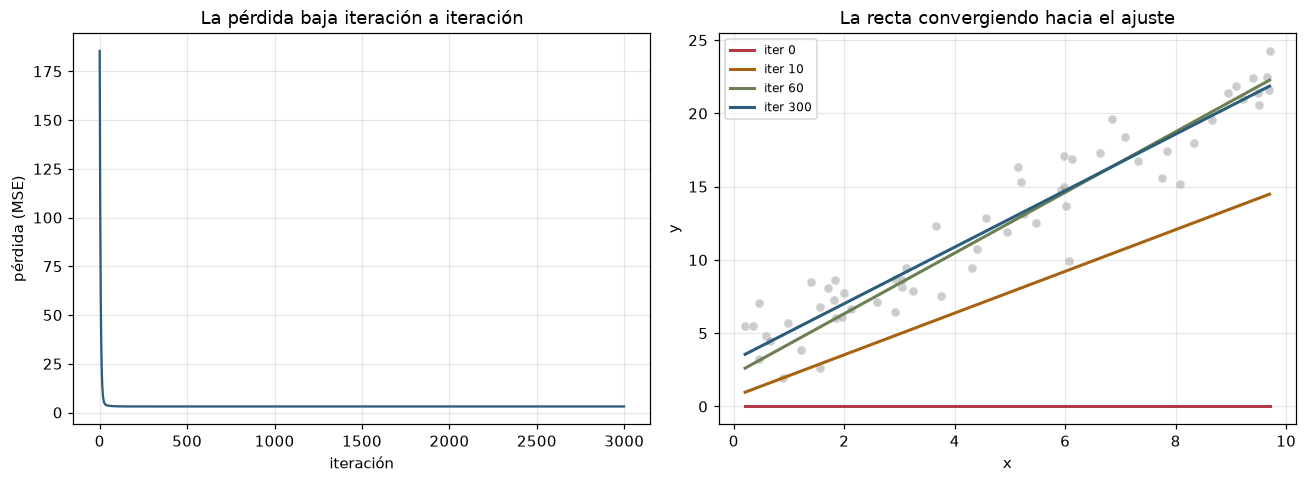

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Curva de pérdida
axes[0].plot(perdidas, color="#2C5D7C")
axes[0].set_xlabel("iteración"); axes[0].set_ylabel("pérdida (MSE)")
axes[0].set_title("La pérdida baja iteración a iteración")

# Snapshots de la recta durante el entrenamiento
colores = ["#B23A48", "#A66412", "#6B7F52", "#2C5D7C"]
axes[1].scatter(x, y, alpha=0.4, edgecolor="white", color="gray", zorder=1)
for (it, b0_i, b1_i), c in zip(historial, colores):
    axes[1].plot(x_linea, b0_i + b1_i * x_linea, color=c, linewidth=2, label=f"iter {it}")
axes[1].set_title("La recta convergiendo hacia el ajuste")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()


**La idea clave a quedarnos:** entrenar un modelo de ML —desde esta regresión de 2
parámetros hasta una red con miles de ellos— es, en el fondo, siempre esto mismo: *definir una
pérdida, calcular su gradiente, y dar pasos que la reduzcan, una y otra vez.*


## 3. Regresión lineal múltiple

### 3.1 El modelo, en notación matricial

Con $p$ variables explicativas, cada observación tiene un vector de predictores
$(x_{i1},\dots,x_{ip})$. Escribimos el modelo para las $n$ observaciones a la vez como:

$$\mathbf{y} = \mathbf{X}\boldsymbol\beta + \boldsymbol\varepsilon$$

donde $\mathbf{X}$ es la **matriz de diseño** ($n \times (p+1)$: una fila por observación, una
columna por variable, más una primera columna de unos para el intercepto), y
$\boldsymbol\beta = (\beta_0,\beta_1,\dots,\beta_p)^\top$.

### 3.2 La ecuación normal (derivación)

Minimizamos $S(\boldsymbol\beta) = (\mathbf y - \mathbf X\boldsymbol\beta)^\top(\mathbf y - \mathbf X\boldsymbol\beta)$.
Derivando respecto al vector $\boldsymbol\beta$ e igualando a cero:

$$\nabla S = -2\mathbf X^\top(\mathbf y - \mathbf X\boldsymbol\beta) = 0
\;\Rightarrow\; \mathbf X^\top \mathbf X\, \boldsymbol\beta = \mathbf X^\top \mathbf y$$

$$\boxed{\boldsymbol\beta = (\mathbf X^\top \mathbf X)^{-1} \mathbf X^\top \mathbf y}$$

Es la **generalización matricial exacta** de las fórmulas de la sección 1.3 — de hecho, si
$p=1$, esta fórmula matricial se reduce exactamente a aquellas.


In [9]:
# Datos sintéticos con 2 variables y relación VERDADERA conocida:
# y = 5 + 1.5*x1 - 2.0*x2 + ruido
n2 = 120
beta_true = np.array([5.0, 1.5, -2.0])  # [b0, b1, b2]

x1 = np.random.uniform(0, 10, n2)
x2 = np.random.uniform(0, 5, n2)
ruido2 = np.random.normal(0, 1.5, n2)
y2 = beta_true[0] + beta_true[1] * x1 + beta_true[2] * x2 + ruido2

X_raw = np.column_stack([x1, x2])
print(f"Forma de los datos: X={X_raw.shape}, y={y2.shape}")


Forma de los datos: X=(120, 2), y=(120,)


In [10]:
def fit_regresion_multiple(X, y):
    '''Ajusta y = b0 + b1*x1 + ... + bp*xp por ecuación normal.'''
    n = X.shape[0]
    X_diseno = np.column_stack([np.ones(n), X])       # añade la columna de unos (intercepto)
    XtX = X_diseno.T @ X_diseno
    XtX_inv = np.linalg.inv(XtX)                        # np.linalg.inv: álgebra lineal, no "la regresión"
    beta = XtX_inv @ X_diseno.T @ y
    return beta  # [b0, b1, ..., bp]

beta_hat = fit_regresion_multiple(X_raw, y2)
print("Verdadero: ", np.round(beta_true, 3))
print("Estimado:  ", np.round(beta_hat, 3))


Verdadero:  [ 5.   1.5 -2. ]
Estimado:   [ 4.657  1.492 -1.792]


### 3.3 Visualización en 3D

Con 2 variables explicativas, el modelo deja de ser una recta y pasa a ser un **plano** en el
espacio $(x_1, x_2, y)$. Podemos verlo directamente.


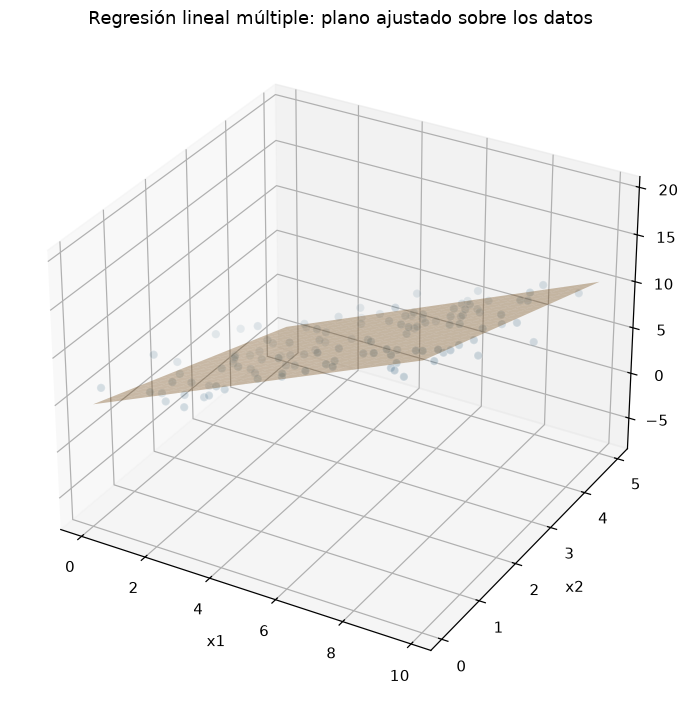

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necesario para proyección 3d)

fig = plt.figure(figsize=(8, 6.5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x1, x2, y2, alpha=0.5, color="#2C5D7C", edgecolor="white", s=30)

x1_grid, x2_grid = np.meshgrid(np.linspace(x1.min(), x1.max(), 20),
                                np.linspace(x2.min(), x2.max(), 20))
y_grid = beta_hat[0] + beta_hat[1] * x1_grid + beta_hat[2] * x2_grid
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.35, color="#A66412")

ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
ax.set_title("Regresión lineal múltiple: plano ajustado sobre los datos")
plt.tight_layout(); plt.show()


### 3.4 Residuos y $R^2$ (igual que en la simple, generalizado)


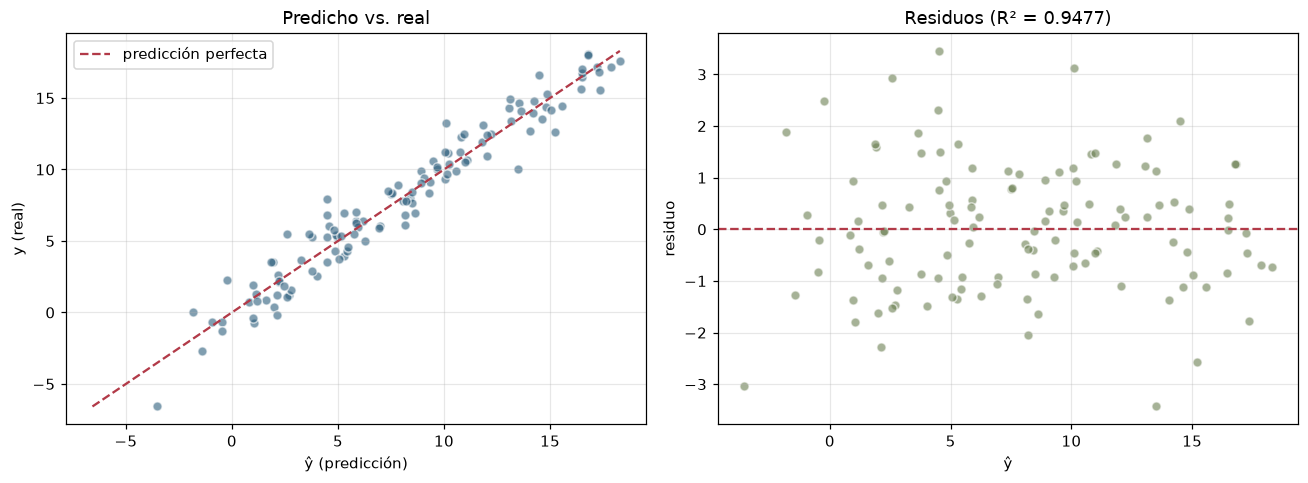

R² = 0.9477


In [12]:
X_diseno = np.column_stack([np.ones(n2), X_raw])
y2_pred = X_diseno @ beta_hat
residuos2 = y2 - y2_pred

ss_res2 = np.sum(residuos2 ** 2)
ss_tot2 = np.sum((y2 - y2.mean()) ** 2)
r2_multiple = 1 - ss_res2 / ss_tot2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y2_pred, y2, alpha=0.6, edgecolor="white", color="#2C5D7C")
lims = [min(y2.min(), y2_pred.min()), max(y2.max(), y2_pred.max())]
axes[0].plot(lims, lims, color="#B23A48", linestyle="--", label="predicción perfecta")
axes[0].set_xlabel("ŷ (predicción)"); axes[0].set_ylabel("y (real)")
axes[0].set_title("Predicho vs. real"); axes[0].legend()

axes[1].scatter(y2_pred, residuos2, alpha=0.6, edgecolor="white", color="#6B7F52")
axes[1].axhline(0, color="#B23A48", linestyle="--")
axes[1].set_xlabel("ŷ"); axes[1].set_ylabel("residuo")
axes[1].set_title(f"Residuos (R² = {r2_multiple:.4f})")

plt.tight_layout(); plt.show()
print(f"R² = {r2_multiple:.4f}")


## 4. Verificación contra `scikit-learn`

Un buen hábito científico: confirmar que la implementación manual coincide con una librería de
referencia, ampliamente probada. **Esto no sustituye el trabajo manual de arriba — lo valida.**


In [13]:
from sklearn.linear_model import LinearRegression

# --- verificación regresión simple ---
modelo_simple = LinearRegression().fit(x.reshape(-1, 1), y)
print("=== Regresión simple ===")
print(f"Manual (ec. normales): b0={b0_hat:.6f}  b1={b1_hat:.6f}")
print(f"Manual (grad. desc.):  b0={b0_gd:.6f}  b1={b1_gd:.6f}")
print(f"scikit-learn:          b0={modelo_simple.intercept_:.6f}  b1={modelo_simple.coef_[0]:.6f}")

# --- verificación regresión múltiple ---
modelo_multiple = LinearRegression().fit(X_raw, y2)
print("\n=== Regresión múltiple ===")
print(f"Manual (ec. normal):  {np.round(beta_hat, 6)}")
print(f"scikit-learn:         [{modelo_multiple.intercept_:.6f}, {modelo_multiple.coef_[0]:.6f}, {modelo_multiple.coef_[1]:.6f}]")


=== Regresión simple ===
Manual (ec. normales): b0=3.177304  b1=1.925616
Manual (grad. desc.):  b0=3.177304  b1=1.925616
scikit-learn:          b0=3.177304  b1=1.925616

=== Regresión múltiple ===
Manual (ec. normal):  [ 4.657499  1.492499 -1.792031]
scikit-learn:         [4.657499, 1.492499, -1.792031]


## 5. Conexión con el TFM

El modelo que usaremos para la previsión de demanda (documento `explicacion_tecnica`, sección 5)
es un **MLP con embeddings** — en esencia, una cadena de transformaciones lineales como
$\mathbf X\boldsymbol\beta$ intercaladas con no-linealidades (ReLU). Lo que lo hace más
potente que esta regresión no es el *principio* de entrenamiento (sigue siendo minimizar una
pérdida por descenso de gradiente, exactamente como en la Sección 2), sino:

- **Más parámetros** organizados en capas, en vez de un solo vector $\beta$.
- **No-linealidades** (ReLU) entre capas, que permiten capturar relaciones que un plano no puede.
- Un optimizador más sofisticado que el descenso de gradiente simple (**Adam**), que ajusta la
  tasa de aprendizaje de forma adaptativa — pero conceptualmente sigue siendo "dar pasos que
  bajan la pérdida", solo que con pasos más inteligentes.
- En el escenario **federado**, ese mismo bucle de entrenamiento se repite dentro de cada silo,
  y lo que se promedia entre silos (FedAvg) son exactamente los parámetros equivalentes a
  nuestro $\boldsymbol\beta$ — pesos numéricos, nunca los datos.

Si esta regresión de dos parámetros tiene sentido para ti, el MLP del proyecto es "lo mismo,
pero con más piezas".
